In [1]:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl joblib

**IMPORT**


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

sns.set_theme(
    style="whitegrid"
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import pandas as pd

FILE_PATH = r"dataset/ClaimShieldAI-Dataset.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (40038, 16)


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Risk_Score,Fraud_Flag,Claim_Status,Settlement_Amount
0,CLM000001,CUST018311,POL0285346,79,Male,West,Home,3264.23,56380.37,8140.64,Accident,529,91.93,Yes,Under Review,4330.86
1,CLM000002,CUST003854,POL0518267,78,Female,West,Home,4937.85,98556.51,32997.15,Accident,331,82.90,Yes,Under Review,30106.34
2,CLM000003,CUST018067,POL0278802,57,Male,West,Health,3952.90,33481.54,14873.17,Property,642,30.69,No,Approved,10424.77
3,CLM000006,CUST004514,POL0823407,75,Female,East,Life,4680.15,38669.97,1783.29,Medical,342,47.91,No,Approved,1668.27
4,CLM000007,CUST015293,POL0112837,46,Female,West,Health,1886.92,72717.24,9550.18,Medical,528,40.18,No,Approved,8157.69


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")

for col in df.columns:
    print(" -", col)

print("\nData types:")

display(
    df.dtypes.to_frame(
        "Data_Type"
    )
)

Number of rows: 40038
Number of columns: 16

Columns:
 - Claim_ID
 - Customer_ID
 - Policy_Number
 - Age
 - Gender
 - Region
 - Policy_Type
 - Premium_Amount
 - Coverage_Amount
 - Claim_Amount
 - Claim_Type
 - Credit_Score
 - Fraud_Risk_Score
 - Fraud_Flag
 - Claim_Status
 - Settlement_Amount

Data types:


,Data_Type
Claim_ID,str
Customer_ID,str
Policy_Number,str
Age,int64
Gender,str
Region,str
Policy_Type,str
Premium_Amount,float64
Coverage_Amount,float64
Claim_Amount,float64


In [5]:
EXPECTED_COLUMNS = [
    "Claim_ID",
    "Customer_ID",
    "Policy_Number",
    "Age",
    "Gender",
    "Region",
    "Policy_Type",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Claim_Type",
    "Credit_Score",
    "Fraud_Risk_Score",
    "Fraud_Flag",
    "Claim_Status",
    "Settlement_Amount"
]

missing_columns = [
    col
    for col in EXPECTED_COLUMNS
    if col not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print(
    "All expected columns are present."
)

All expected columns are present.


In [6]:
missing_report = pd.DataFrame({

    "Column": df.columns,

    "Missing_Count":
        df.isnull().sum(),

    "Missing_Percentage":
        (
            df.isnull().sum()
            /
            len(df)
            *
            100
        )
})

display(
    missing_report
)

,Column,Missing_Count,Missing_Percentage
Claim_ID,Claim_ID,0,0.0
Customer_ID,Customer_ID,0,0.0
Policy_Number,Policy_Number,0,0.0
Age,Age,0,0.0
Gender,Gender,0,0.0
Region,Region,0,0.0
Policy_Type,Policy_Type,0,0.0
Premium_Amount,Premium_Amount,0,0.0
Coverage_Amount,Coverage_Amount,0,0.0
Claim_Amount,Claim_Amount,0,0.0


In [7]:
duplicate_count = (
    df.duplicated().sum()
)

print(
    "Duplicate rows:",
    duplicate_count
)

Duplicate rows: 0


In [8]:
print(
    "Unique Fraud_Flag values:"
)

print(
    df["Fraud_Flag"].unique()
)

df["Target"] = (
    df["Fraud_Flag"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

if df["Target"].isnull().any():

    raise ValueError(
        "Unexpected values found in Fraud_Flag."
    )

print(
    "\nTarget successfully created."
)

display(
    df["Target"]
    .value_counts()
)

Unique Fraud_Flag values:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Target successfully created.


Target
0    30102
1     9936
Name: count, dtype: int64

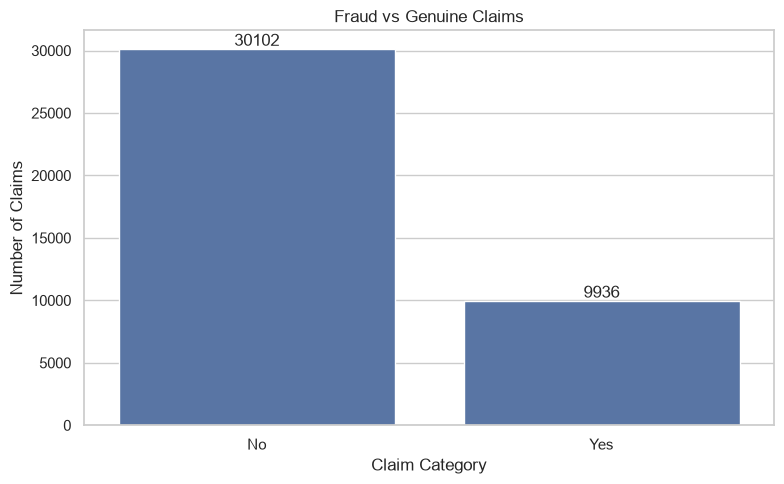

In [9]:
fraud_counts = (
    df["Fraud_Flag"]
    .value_counts()
)

plt.figure(
    figsize=(8, 5)
)

ax = sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title(
    "Fraud vs Genuine Claims"
)

plt.xlabel(
    "Claim Category"
)

plt.ylabel(
    "Number of Claims"
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%d"
    )

plt.tight_layout()
plt.show()

In [10]:
class_counts = (
    df["Target"]
    .value_counts()
)

genuine_count = class_counts.get(
    0,
    0
)

fraud_count = class_counts.get(
    1,
    0
)

fraud_percentage = (
    fraud_count
    /
    len(df)
    *
    100
)

genuine_percentage = (
    genuine_count
    /
    len(df)
    *
    100
)

print(
    f"Genuine claims: {genuine_count:,}"
)

print(
    f"Fraud claims: {fraud_count:,}"
)

print(
    f"Genuine percentage: "
    f"{genuine_percentage:.2f}%"
)

print(
    f"Fraud percentage: "
    f"{fraud_percentage:.2f}%"
)

Genuine claims: 30,102
Fraud claims: 9,936
Genuine percentage: 75.18%
Fraud percentage: 24.82%


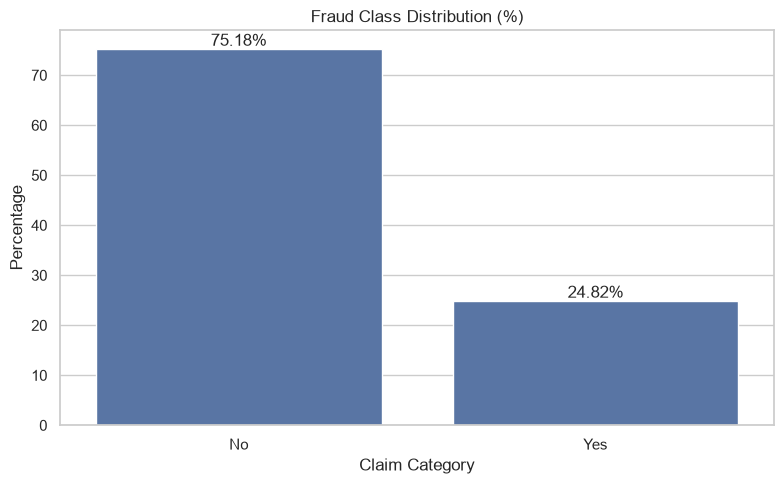

In [11]:
class_percentage = (
    df["Fraud_Flag"]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .reset_index()
)

class_percentage.columns = [
    "Fraud_Flag",
    "Percentage"
]

plt.figure(
    figsize=(8, 5)
)

ax = sns.barplot(
    data=class_percentage,
    x="Fraud_Flag",
    y="Percentage"
)

plt.title(
    "Fraud Class Distribution (%)"
)

plt.xlabel(
    "Claim Category"
)

plt.ylabel(
    "Percentage"
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.2f%%"
    )

plt.tight_layout()
plt.show()

**NUMERICAL EDA**

In [12]:
numeric_columns = [
    "Age",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Credit_Score"
]

display(
    df[numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Age,40038.0,48.581098,17.895157,18.00,33.0000,49.000,64.0000,79.00
Premium_Amount,40038.0,2601.250431,1387.997986,200.05,1399.7475,2597.230,3806.4650,4999.86
Coverage_Amount,40038.0,52751.360253,27508.339738,5001.71,29001.7875,52781.920,76737.9525,99985.96
Claim_Amount,40038.0,25127.953153,14385.708702,501.24,12598.7375,25062.305,37602.8325,49999.17
Credit_Score,40038.0,575.778960,159.406824,300.00,437.0000,576.000,714.0000,849.00


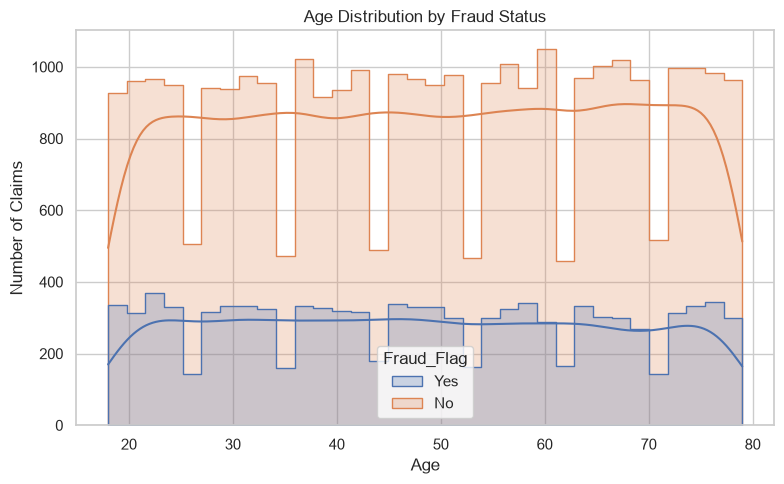

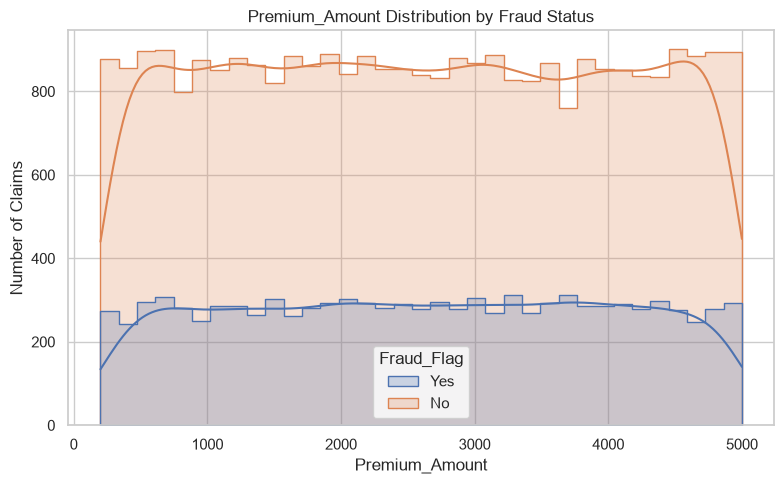

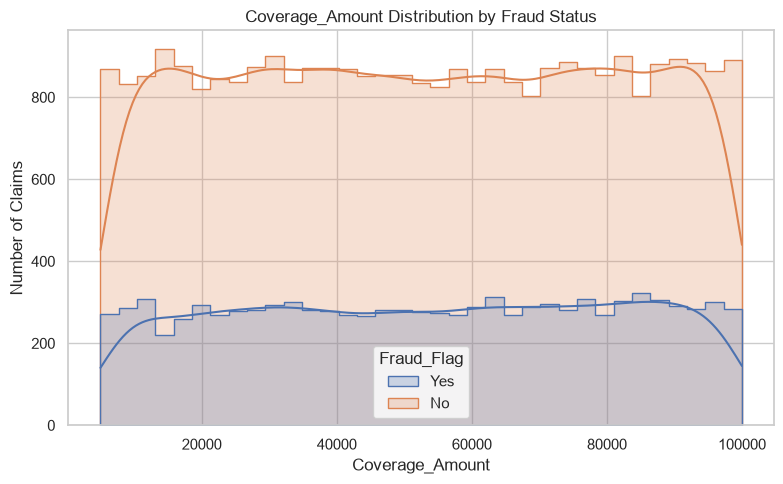

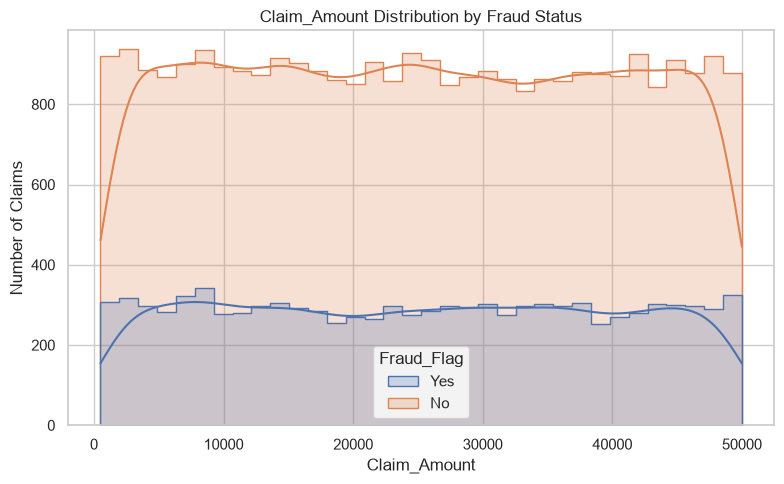

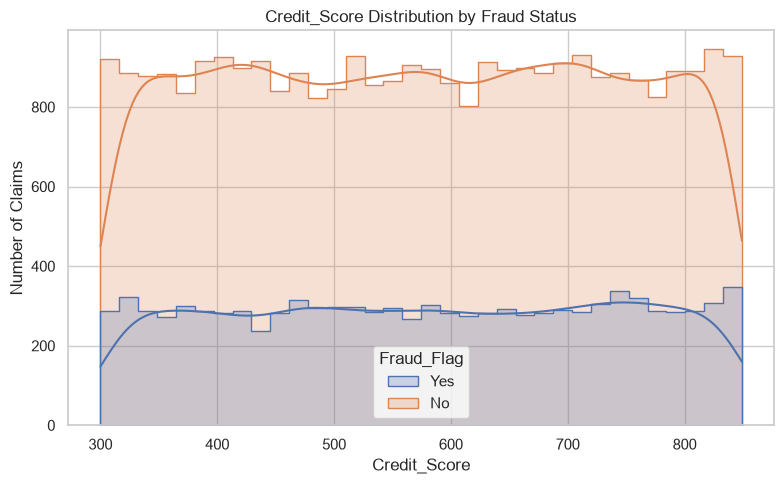

In [13]:
for column in numeric_columns:

    plt.figure(
        figsize=(8, 5)
    )

    sns.histplot(
        data=df,
        x=column,
        hue="Fraud_Flag",
        kde=True,
        element="step"
    )

    plt.title(
        f"{column} Distribution by Fraud Status"
    )

    plt.xlabel(
        column
    )

    plt.ylabel(
        "Number of Claims"
    )

    plt.tight_layout()
    plt.show()

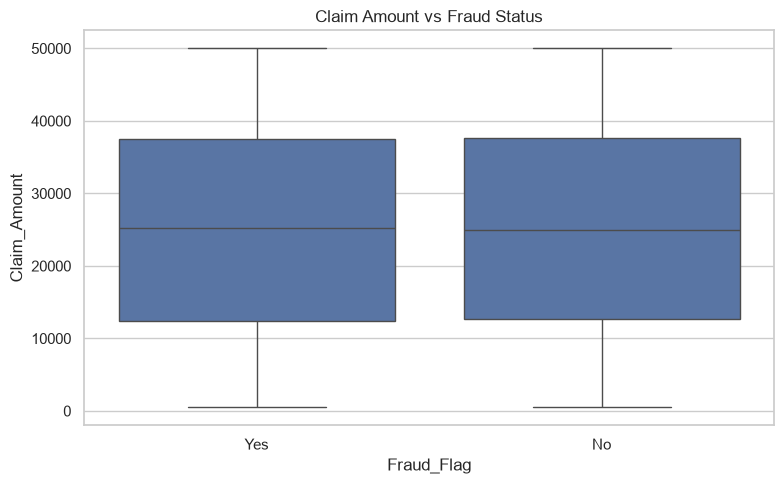

In [14]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=df,
    x="Fraud_Flag",
    y="Claim_Amount"
)

plt.title(
    "Claim Amount vs Fraud Status"
)

plt.tight_layout()
plt.show()

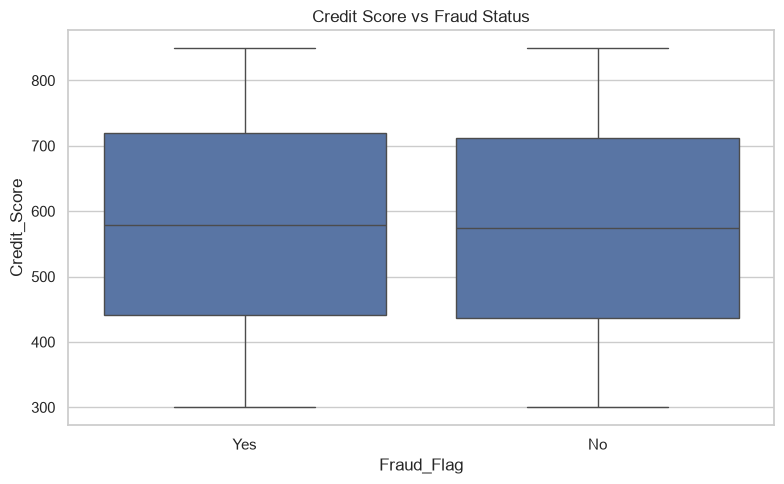

In [15]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=df,
    x="Fraud_Flag",
    y="Credit_Score"
)

plt.title(
    "Credit Score vs Fraud Status"
)

plt.tight_layout()
plt.show()

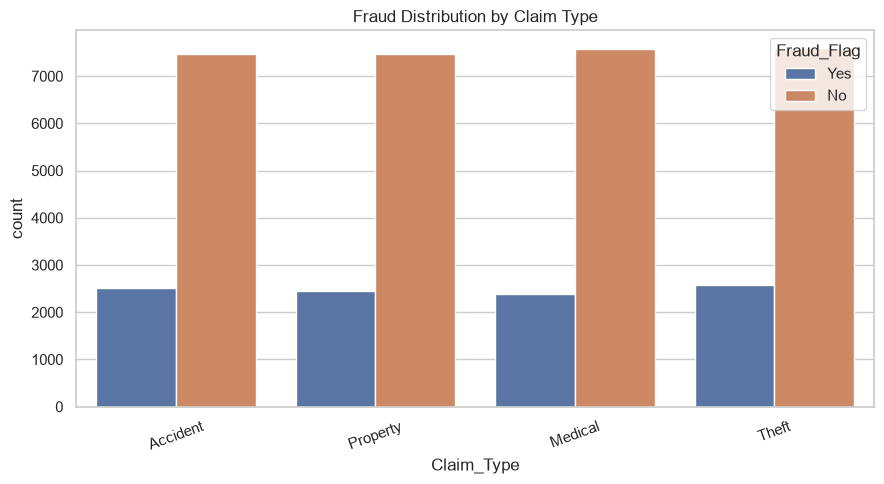

In [16]:
plt.figure(
    figsize=(9, 5)
)

sns.countplot(
    data=df,
    x="Claim_Type",
    hue="Fraud_Flag"
)

plt.title(
    "Fraud Distribution by Claim Type"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

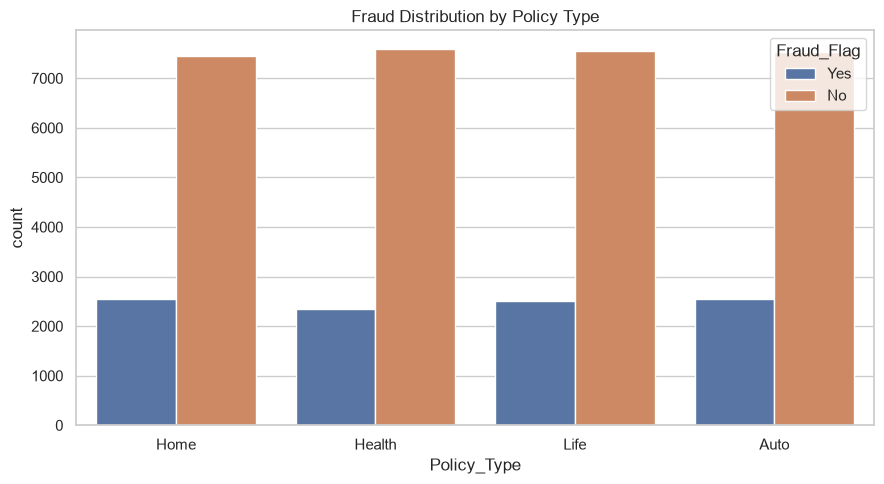

In [17]:
plt.figure(
    figsize=(9, 5)
)

sns.countplot(
    data=df,
    x="Policy_Type",
    hue="Fraud_Flag"
)

plt.title(
    "Fraud Distribution by Policy Type"
)

plt.tight_layout()
plt.show()

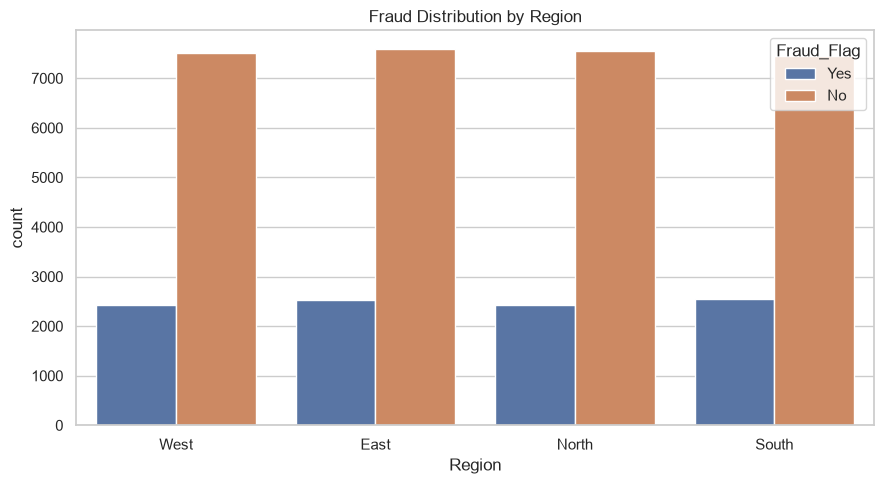

In [18]:
plt.figure(
    figsize=(9, 5)
)

sns.countplot(
    data=df,
    x="Region",
    hue="Fraud_Flag"
)

plt.title(
    "Fraud Distribution by Region"
)

plt.tight_layout()
plt.show()

In [19]:
correlation_columns = [
    "Age",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Credit_Score",
    "Target"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

display(
    correlation_matrix
)

,Age,Premium_Amount,Coverage_Amount,Claim_Amount,Credit_Score,Target
Age,1.000000,0.011691,-0.000843,0.003591,0.005024,-0.015674
Premium_Amount,0.011691,1.000000,-0.005899,0.005220,-0.001052,0.003751
Coverage_Amount,-0.000843,-0.005899,1.000000,-0.008023,0.000668,0.009493
Claim_Amount,0.003591,0.005220,-0.008023,1.000000,0.003446,-0.000045
Credit_Score,0.005024,-0.001052,0.000668,0.003446,1.000000,0.007251
Target,-0.015674,0.003751,0.009493,-0.000045,0.007251,1.000000


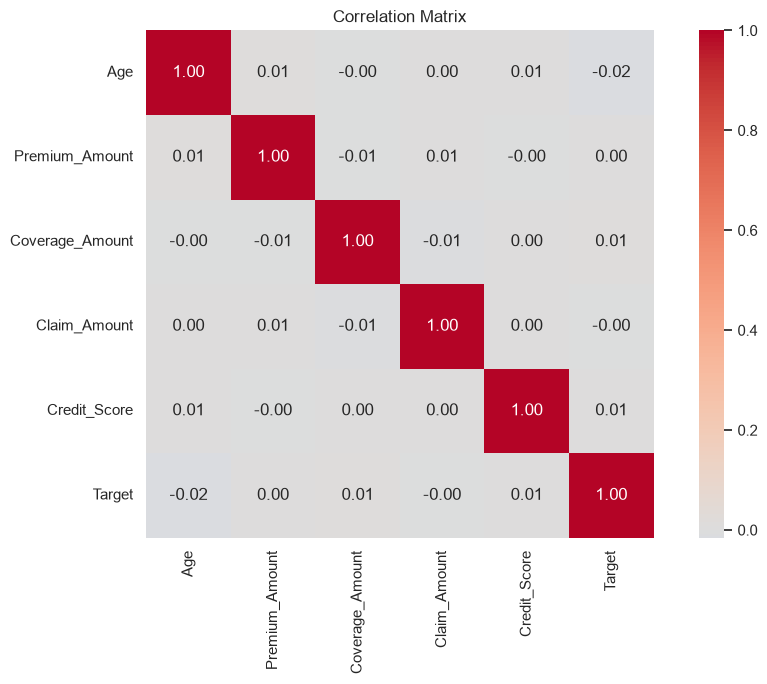

In [20]:
plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [21]:
LEGACY_COLUMNS = [
    "Fraud_Risk_Score",
    "Claim_Status",
    "Settlement_Amount"
]

IDENTIFIER_COLUMNS = [
    "Claim_ID",
    "Customer_ID",
    "Policy_Number"
]

TARGET_COLUMN = "Fraud_Flag"

print(
    "Legacy/reference columns:"
)

for col in LEGACY_COLUMNS:
    print(
        " -",
        col
    )

print(
    "\nIdentifier columns:"
)

for col in IDENTIFIER_COLUMNS:
    print(
        " -",
        col
    )

Legacy/reference columns:
 - Fraud_Risk_Score
 - Claim_Status
 - Settlement_Amount

Identifier columns:
 - Claim_ID
 - Customer_ID
 - Policy_Number


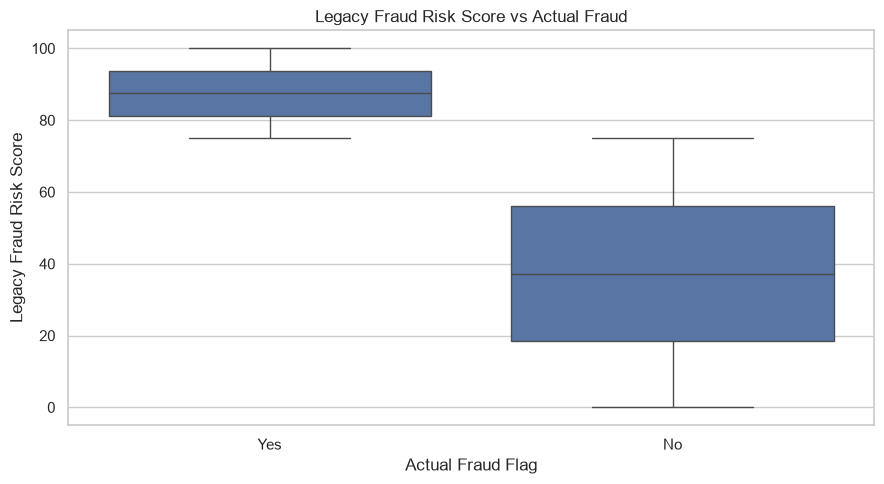

In [22]:
plt.figure(
    figsize=(9, 5)
)

sns.boxplot(
    data=df,
    x="Fraud_Flag",
    y="Fraud_Risk_Score"
)

plt.title(
    "Legacy Fraud Risk Score vs Actual Fraud"
)

plt.xlabel(
    "Actual Fraud Flag"
)

plt.ylabel(
    "Legacy Fraud Risk Score"
)

plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

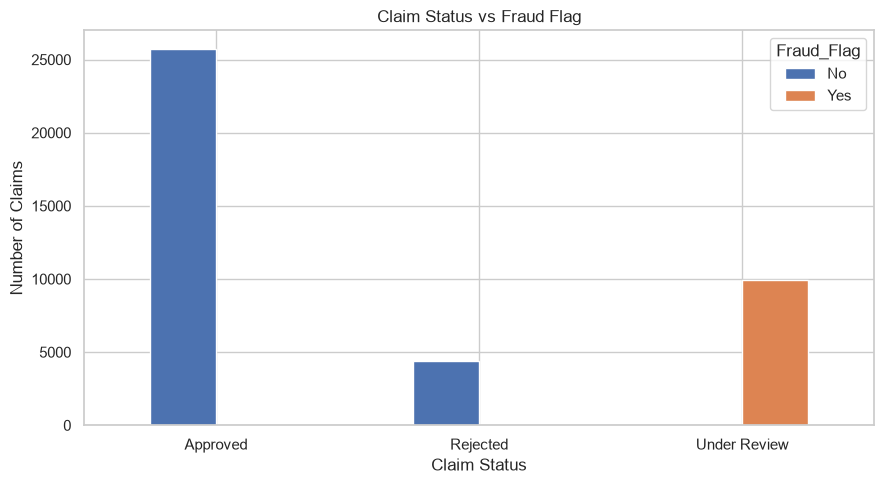

In [23]:
status_fraud = pd.crosstab(
    df["Claim_Status"],
    df["Fraud_Flag"]
)

plt.figure(
    figsize=(9, 5)
)

status_fraud.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Claim Status vs Fraud Flag"
)

plt.xlabel(
    "Claim Status"
)

plt.ylabel(
    "Number of Claims"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

**QUANTIFYING THE LEGACY-COLUMN SIGNAL**

In [24]:
# ============================================================
# LEAKAGE DIAGNOSTIC — how much signal is really in
# Fraud_Risk_Score, vs. the genuinely "production-safe" columns?
# ============================================================

match_rate = (
    (
        (df["Fraud_Risk_Score"] > 75)
        .map({True: "Yes", False: "No"})
    )
    == df["Fraud_Flag"]
).mean()

print(
    "Rule 'Fraud_Risk_Score > 75' reproduces Fraud_Flag",
    f"{match_rate * 100:.2f}% of the time"
)

print(
    "Min Fraud_Risk_Score when Fraud_Flag == Yes:",
    df.loc[df["Fraud_Flag"] == "Yes", "Fraud_Risk_Score"].min()
)

print(
    "Max Fraud_Risk_Score when Fraud_Flag == No:",
    df.loc[df["Fraud_Flag"] == "No", "Fraud_Risk_Score"].max()
)

print()
print("Correlation of the genuinely production-safe columns with Target:")

legit_numeric = [
    "Age",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Credit_Score"
]

display(
    df[legit_numeric + ["Target"]]
    .corr()["Target"]
    .drop("Target")
    .sort_values()
    .to_frame("Correlation_with_Target")
)

print(
    "\nInterpretation: Fraud_Risk_Score alone reproduces the label "
    "almost perfectly, while every other column is essentially "
    "uncorrelated with it. That is the signature of the label "
    "having been generated FROM Fraud_Risk_Score — i.e. target "
    "leakage, not an independent legacy signal. That is why it "
    "stays out of FINAL_FEATURES below, and why the leakage-free "
    "production model's accuracy/recall is capped by how little "
    "real signal the remaining columns contain (see the final "
    "summary at the end of this notebook)."
)


Rule 'Fraud_Risk_Score > 75' reproduces Fraud_Flag 100.00% of the time
Min Fraud_Risk_Score when Fraud_Flag == Yes: 75.01
Max Fraud_Risk_Score when Fraud_Flag == No: 75.0

Correlation of the genuinely production-safe columns with Target:


,Correlation_with_Target
Age,-0.015674
Claim_Amount,-0.000045
Premium_Amount,0.003751
Credit_Score,0.007251
Coverage_Amount,0.009493



Interpretation: Fraud_Risk_Score alone reproduces the label almost perfectly, while every other column is essentially uncorrelated with it. That is the signature of the label having been generated FROM Fraud_Risk_Score — i.e. target leakage, not an independent legacy signal. That is why it stays out of FINAL_FEATURES below, and why the leakage-free production model's accuracy/recall is capped by how little real signal the remaining columns contain (see the final summary at the end of this notebook).


**IMPORTANT: Leakage experiment**

**This experiment is only for demonstrating the effect of legacy information.**

In [25]:
LEAKAGE_FEATURES = [
    "Age",
    "Gender",
    "Region",
    "Policy_Type",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Claim_Type",
    "Credit_Score",

    # Legacy/reference information
    "Fraud_Risk_Score",
    "Claim_Status",
    "Settlement_Amount"
]

X_leakage = df[
    LEAKAGE_FEATURES
].copy()

y = df[
    "Target"
].copy()

print(
    "Leakage experiment features:",
    len(LEAKAGE_FEATURES)
)

display(
    X_leakage.head()
)

Leakage experiment features: 12


,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Risk_Score,Claim_Status,Settlement_Amount
0,79,Male,West,Home,3264.23,56380.37,8140.64,Accident,529,91.93,Under Review,4330.86
1,78,Female,West,Home,4937.85,98556.51,32997.15,Accident,331,82.90,Under Review,30106.34
2,57,Male,West,Health,3952.90,33481.54,14873.17,Property,642,30.69,Approved,10424.77
3,75,Female,East,Life,4680.15,38669.97,1783.29,Medical,342,47.91,Approved,1668.27
4,46,Female,West,Health,1886.92,72717.24,9550.18,Medical,528,40.18,Approved,8157.69


In [26]:
def create_encoder():

    try:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )

    except TypeError:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


def create_preprocessor(
    X_data
):

    numeric_features = (
        X_data
        .select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    categorical_features = (
        X_data
        .select_dtypes(
            include="object"
        )
        .columns
        .tolist()
    )

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            create_encoder()
        )
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ])

In [27]:
leakage_rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=14,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced",

    max_features="sqrt",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

leakage_rf_pipeline = Pipeline([

    (
        "preprocessing",
        create_preprocessor(
            X_leakage
        )
    ),

    (
        "model",
        leakage_rf
    )
])

leakage_rf_pipeline.fit(
    X_leakage,
    y
)

leakage_rf_probability = (
    leakage_rf_pipeline
    .predict_proba(
        X_leakage
    )[:, 1]
)

print(
    "Leakage Random Forest trained."
)

Leakage Random Forest trained.


In [28]:
scale_pos_weight = (
    (y == 0).sum()
    /
    (y == 1).sum()
)

leakage_xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="aucpr",

    n_estimators=500,

    learning_rate=0.03,

    max_depth=3,

    min_child_weight=3,

    subsample=0.90,

    colsample_bytree=0.90,

    reg_alpha=0.10,

    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

leakage_xgb_pipeline = Pipeline([

    (
        "preprocessing",
        create_preprocessor(
            X_leakage
        )
    ),

    (
        "model",
        leakage_xgb
    )
])

leakage_xgb_pipeline.fit(
    X_leakage,
    y
)

leakage_xgb_probability = (
    leakage_xgb_pipeline
    .predict_proba(
        X_leakage
    )[:, 1]
)

print(
    "Leakage XGBoost trained."
)

Leakage XGBoost trained.


In [29]:
def calculate_metrics(
    y_true,
    probability,
    threshold=0.50
):

    prediction = (
        probability >= threshold
    ).astype(int)

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                prediction
            ),

        "Precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "F2":
            fbeta_score(
                y_true,
                prediction,
                beta=2,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probability
            )
    }


leakage_comparison = pd.DataFrame([

    {
        "Experiment":
            "Leakage + Random Forest",

        **calculate_metrics(
            y,
            leakage_rf_probability
        )
    },

    {
        "Experiment":
            "Leakage + XGBoost",

        **calculate_metrics(
            y,
            leakage_xgb_probability
        )
    }
])

display(
    leakage_comparison.round(4)
)

,Experiment,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,Leakage + Random Forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Leakage + XGBoost,1.0,1.0,1.0,1.0,1.0,1.0,1.0


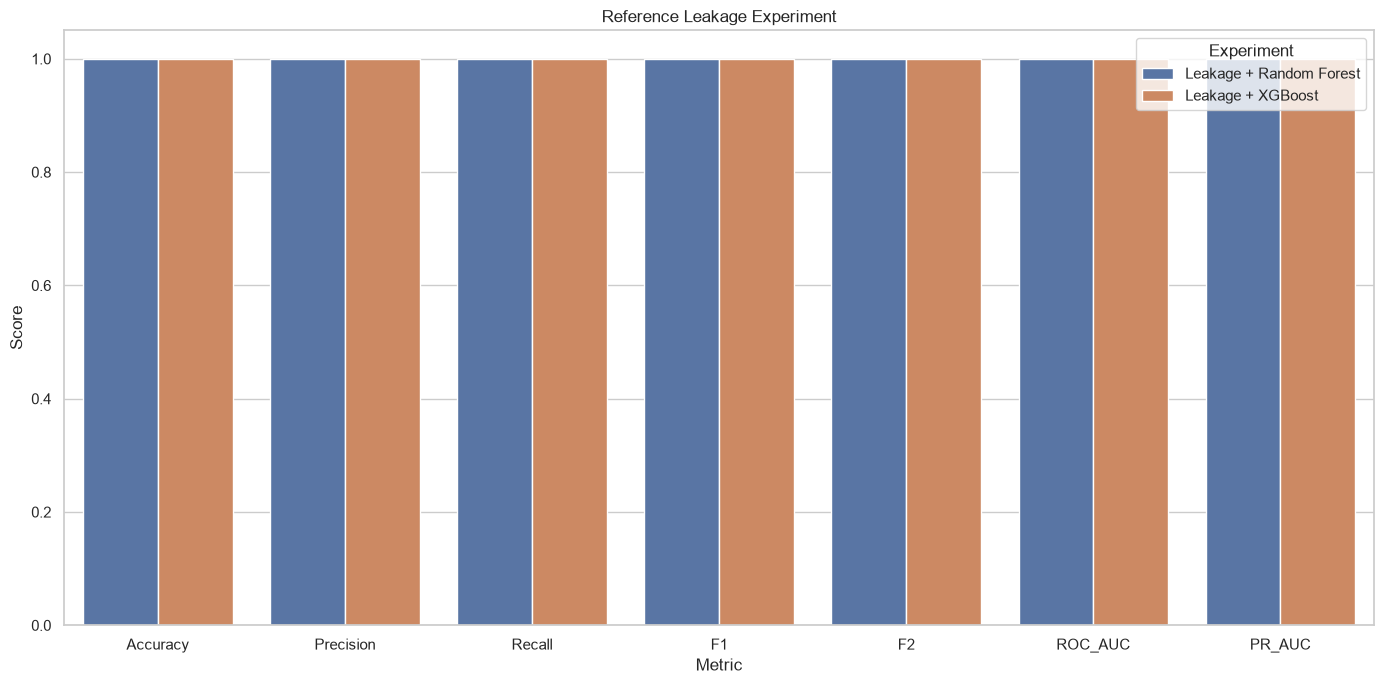

In [30]:
leakage_plot = leakage_comparison.melt(
    id_vars="Experiment",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "ROC_AUC",
        "PR_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=leakage_plot,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.title(
    "Reference Leakage Experiment"
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()
plt.show()

**Production feature enginering**

In [31]:
def engineer_features(
    data
):

    data = data.copy()

    data[
        "Claim_Coverage_Ratio"
    ] = (
        data["Claim_Amount"]
        /
        data["Coverage_Amount"]
        .replace(
            0,
            np.nan
        )
    )

    data[
        "Claim_Premium_Ratio"
    ] = (
        data["Claim_Amount"]
        /
        data["Premium_Amount"]
        .replace(
            0,
            np.nan
        )
    )

    data[
        "Coverage_Premium_Ratio"
    ] = (
        data["Coverage_Amount"]
        /
        data["Premium_Amount"]
        .replace(
            0,
            np.nan
        )
    )

    data[
        "Remaining_Coverage"
    ] = (
        data["Coverage_Amount"]
        -
        data["Claim_Amount"]
    )

    data[
        "Young_Customer"
    ] = (
        data["Age"] < 30
    ).astype(int)

    data[
        "Senior_Customer"
    ] = (
        data["Age"] >= 60
    ).astype(int)

    data[
        "Low_Credit_Score"
    ] = (
        data["Credit_Score"] < 600
    ).astype(int)

    data[
        "High_Claim"
    ] = (
        data["Claim_Amount"] >= 100000
    ).astype(int)

    data.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

    return data

In [32]:
model_df = engineer_features(
    df
)

BASE_FEATURES = [

    "Age",
    "Gender",
    "Region",
    "Policy_Type",
    "Premium_Amount",
    "Coverage_Amount",
    "Claim_Amount",
    "Claim_Type",
    "Credit_Score"
]

ENGINEERED_FEATURES = [

    "Claim_Coverage_Ratio",
    "Claim_Premium_Ratio",
    "Coverage_Premium_Ratio",
    "Remaining_Coverage",
    "Young_Customer",
    "Senior_Customer",
    "Low_Credit_Score",
    "High_Claim"
]

FINAL_FEATURES = (
    BASE_FEATURES
    +
    ENGINEERED_FEATURES
)

X = model_df[
    FINAL_FEATURES
].copy()

y = model_df[
    "Target"
].copy()

print(
    "Production features:",
    len(FINAL_FEATURES)
)

display(
    X.head()
)

Production features: 17


,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Claim_Coverage_Ratio,Claim_Premium_Ratio,Coverage_Premium_Ratio,Remaining_Coverage,Young_Customer,Senior_Customer,Low_Credit_Score,High_Claim
0,79,Male,West,Home,3264.23,56380.37,8140.64,Accident,529,0.144388,2.493893,17.272181,48239.73,0,1,1,0
1,78,Female,West,Home,4937.85,98556.51,32997.15,Accident,331,0.334804,6.682493,19.959397,65559.36,0,1,1,0
2,57,Male,West,Health,3952.90,33481.54,14873.17,Property,642,0.444220,3.762597,8.470121,18608.37,0,0,0,0
3,75,Female,East,Life,4680.15,38669.97,1783.29,Medical,342,0.046116,0.381033,8.262549,36886.68,0,1,1,0
4,46,Female,West,Health,1886.92,72717.24,9550.18,Medical,528,0.131333,5.061253,38.537532,63167.06,0,0,1,0


In [33]:
FORBIDDEN_FEATURES = [

    "Fraud_Risk_Score",
    "Fraud_Flag",
    "Claim_Status",
    "Settlement_Amount",

    "Claim_ID",
    "Customer_ID",
    "Policy_Number"
]

leakage_found = [
    col
    for col in FINAL_FEATURES
    if col in FORBIDDEN_FEATURES
]

if leakage_found:

    raise ValueError(
        f"LEAKAGE DETECTED: {leakage_found}"
    )

print(
    "=========================================="
)

print(
    "PRODUCTION LEAKAGE CHECK PASSED"
)

print(
    "=========================================="
)

print(
    "Target excluded: Fraud_Flag"
)

print(
    "Legacy columns excluded:"
)

for col in LEGACY_COLUMNS:
    print(
        " -",
        col
    )

print(
    "Identifiers excluded:"
)

for col in IDENTIFIER_COLUMNS:
    print(
        " -",
        col
    )

PRODUCTION LEAKAGE CHECK PASSED
Target excluded: Fraud_Flag
Legacy columns excluded:
 - Fraud_Risk_Score
 - Claim_Status
 - Settlement_Amount
Identifiers excluded:
 - Claim_ID
 - Customer_ID
 - Policy_Number


In [34]:
production_rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=16,

    min_samples_split=5,

    min_samples_leaf=2,

    max_features="sqrt",

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


production_xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="aucpr",

    n_estimators=500,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=3,

    subsample=0.85,

    colsample_bytree=0.90,

    reg_alpha=0.10,

    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

print(
    "Production models created."
)

Production models created.


In [35]:
def run_oof_cv(
    model,
    X_data,
    y_data,
    model_name
):

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    oof_probability = np.zeros(
        len(X_data)
    )

    fold_results = []

    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        skf.split(
            X_data,
            y_data
        ),
        start=1
    ):

        X_train = X_data.iloc[
            train_idx
        ]

        X_valid = X_data.iloc[
            valid_idx
        ]

        y_train = y_data.iloc[
            train_idx
        ]

        y_valid = y_data.iloc[
            valid_idx
        ]

        preprocessor = (
            create_preprocessor(
                X_train
            )
        )

        pipeline = Pipeline([

            (
                "preprocessing",
                preprocessor
            ),

            (
                "model",
                model
            )
        ])

        pipeline.fit(
            X_train,
            y_train
        )

        probability = (
            pipeline
            .predict_proba(
                X_valid
            )[:, 1]
        )

        oof_probability[
            valid_idx
        ] = probability

        prediction = (
            probability >= 0.50
        ).astype(int)

        fold_results.append({

            "Fold": fold,

            "Accuracy":
                accuracy_score(
                    y_valid,
                    prediction
                ),

            "Precision":
                precision_score(
                    y_valid,
                    prediction,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_valid,
                    prediction,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_valid,
                    prediction,
                    zero_division=0
                ),

            "F2":
                fbeta_score(
                    y_valid,
                    prediction,
                    beta=2,
                    zero_division=0
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_valid,
                    probability
                ),

            "PR_AUC":
                average_precision_score(
                    y_valid,
                    probability
                )
        })

        print(
            f"{model_name} | Fold {fold}/5 complete"
        )

    return (
        oof_probability,
        pd.DataFrame(
            fold_results
        )
    )

In [36]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X,
    y
)

baseline_pred = baseline_model.predict(X)

print("Baseline Accuracy:",
      accuracy_score(y, baseline_pred))

print("Baseline Recall:",
      recall_score(y, baseline_pred, zero_division=0))

print("Fraud prevalence:",
      y.mean())

Baseline Accuracy: 0.7518357560317698
Baseline Recall: 0.0
Fraud prevalence: 0.24816424396823017


In [37]:
rf_oof, rf_cv = run_oof_cv(
    production_rf,
    X,
    y,
    "Random Forest"
)

print(
    "\nRandom Forest CV results:"
)

display(
    rf_cv.round(4)
)

print(
    "\nMean:"
)

display(
    rf_cv
    .drop(
        columns="Fold"
    )
    .mean()
    .to_frame(
        "Mean"
    )
    .round(4)
)

Random Forest | Fold 1/5 complete
Random Forest | Fold 2/5 complete
Random Forest | Fold 3/5 complete
Random Forest | Fold 4/5 complete
Random Forest | Fold 5/5 complete

Random Forest CV results:


,Fold,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,1,0.6556,0.2603,0.2103,0.2326,0.2187,0.5092,0.2534
1,2,0.6676,0.2664,0.1938,0.2244,0.2049,0.5130,0.2550
2,3,0.6482,0.2584,0.2235,0.2397,0.2297,0.5145,0.2580
3,4,0.6629,0.2588,0.1922,0.2206,0.2027,0.5104,0.2548
4,5,0.6561,0.2455,0.1862,0.2118,0.1957,0.5026,0.2519



Mean:


,Mean
Accuracy,0.6581
Precision,0.2579
Recall,0.2012
F1,0.2258
F2,0.2103
ROC_AUC,0.5099
PR_AUC,0.2546


In [38]:
xgb_oof, xgb_cv = run_oof_cv(
    production_xgb,
    X,
    y,
    "XGBoost"
)

print(
    "\nXGBoost CV results:"
)

display(
    xgb_cv.round(4)
)

print(
    "\nMean:"
)

display(
    xgb_cv
    .drop(
        columns="Fold"
    )
    .mean()
    .to_frame(
        "Mean"
    )
    .round(4)
)

XGBoost | Fold 1/5 complete
XGBoost | Fold 2/5 complete
XGBoost | Fold 3/5 complete
XGBoost | Fold 4/5 complete
XGBoost | Fold 5/5 complete

XGBoost CV results:


,Fold,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,1,0.5727,0.2560,0.3783,0.3053,0.3453,0.5116,0.2565
1,2,0.5830,0.2671,0.3900,0.3170,0.3571,0.5134,0.2546
2,3,0.5721,0.2608,0.3951,0.3142,0.3582,0.5142,0.2643
3,4,0.5755,0.2597,0.3840,0.3098,0.3505,0.5078,0.2516
4,5,0.5764,0.2573,0.3749,0.3052,0.3435,0.5077,0.2525



Mean:


,Mean
Accuracy,0.5759
Precision,0.2602
Recall,0.3845
F1,0.3103
F2,0.3509
ROC_AUC,0.5110
PR_AUC,0.2559


In [39]:
production_comparison = pd.DataFrame([

    {
        "Model":
            "Random Forest",

        **calculate_metrics(
            y,
            rf_oof
        )
    },

    {
        "Model":
            "XGBoost",

        **calculate_metrics(
            y,
            xgb_oof
        )
    }
])

display(
    production_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,Random Forest,0.6581,0.2579,0.2012,0.2260,0.2104,0.5098,0.2538
1,XGBoost,0.5759,0.2602,0.3845,0.3103,0.3509,0.5109,0.2549


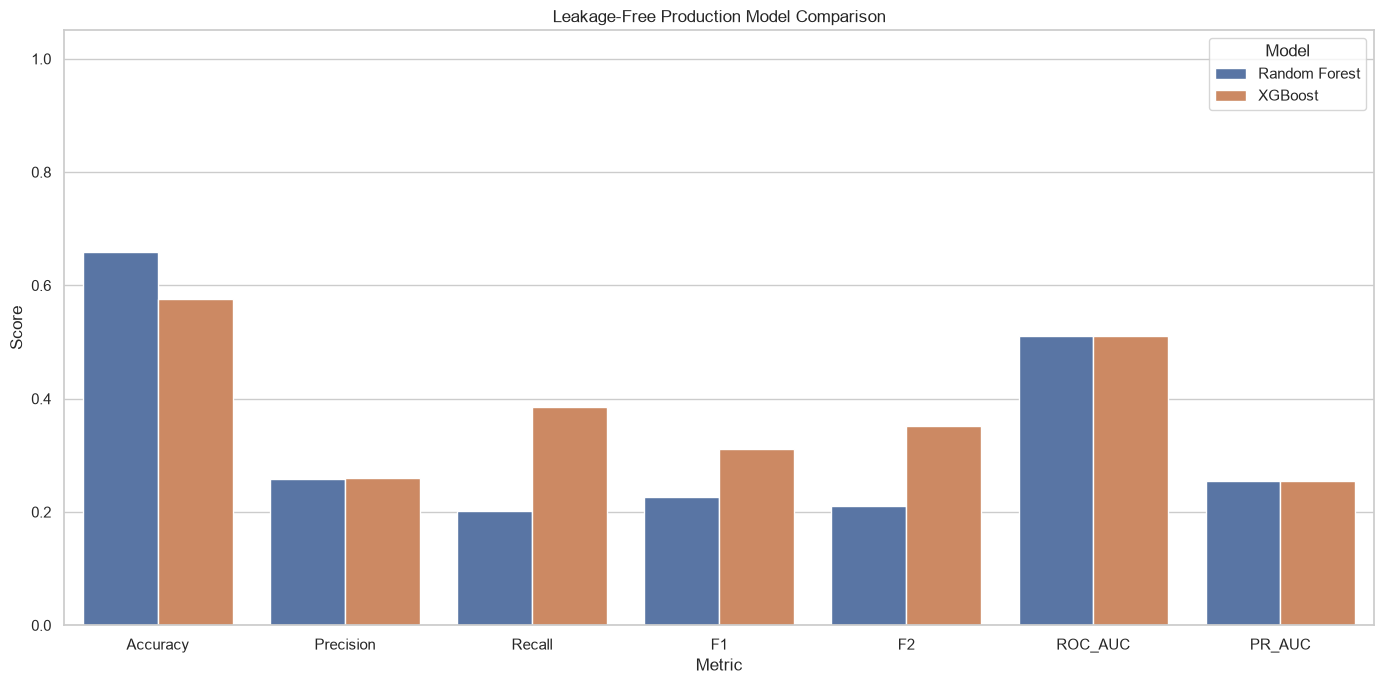

In [40]:
plot_data = production_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "ROC_AUC",
        "PR_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Leakage-Free Production Model Comparison"
)

plt.xlabel(
    "Metric"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()
plt.show()

In [41]:
xgb_tuning_pipeline = Pipeline([

    (
        "preprocessing",
        create_preprocessor(X)
    ),

    (
        "model",
        XGBClassifier(

            objective="binary:logistic",

            eval_metric="aucpr",

            scale_pos_weight=
                scale_pos_weight,

            random_state=
                RANDOM_STATE,

            n_jobs=-1
        )
    )
])

xgb_param_distributions = {

    "model__n_estimators": [
        300,
        500,
        700
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "model__learning_rate": [
        0.02,
        0.03,
        0.05
    ],

    "model__min_child_weight": [
        1,
        3,
        5
    ],

    "model__subsample": [
        0.80,
        0.90,
        1.00
    ],

    "model__colsample_bytree": [
        0.80,
        0.90,
        1.00
    ],

    "model__reg_alpha": [
        0,
        0.1,
        0.5
    ],

    "model__reg_lambda": [
        1,
        2,
        5
    ]
}

tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

random_search = RandomizedSearchCV(

    estimator=xgb_tuning_pipeline,

    param_distributions=
        xgb_param_distributions,

    n_iter=20,

    scoring="average_precision",

    cv=tuning_cv,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=1
)

random_search.fit(
    X,
    y
)

print(
    "Best XGBoost parameters:"
)

print(
    random_search.best_params_
)

print(
    "\nBest CV PR-AUC:"
)

print(
    random_search.best_score_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}

Best CV PR-AUC:
0.2576732305841701


In [42]:
print("Fraud rate:", y.mean())
print("Baseline PR-AUC:", y.mean())
print("Best CV PR-AUC:", random_search.best_score_)
print(random_search.best_params_)

Fraud rate: 0.24816424396823017
Baseline PR-AUC: 0.24816424396823017
Best CV PR-AUC: 0.2576732305841701
{'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}


In [43]:
print("Number of features:", X.shape[1])

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget correlation:")
print(
    pd.concat(
        [
            X,
            y.rename("TARGET")
        ],
        axis=1
    )
    .corr(numeric_only=True)["TARGET"]
    .sort_values()
)

Number of features: 17

Features:
['Age', 'Gender', 'Region', 'Policy_Type', 'Premium_Amount', 'Coverage_Amount', 'Claim_Amount', 'Claim_Type', 'Credit_Score', 'Claim_Coverage_Ratio', 'Claim_Premium_Ratio', 'Coverage_Premium_Ratio', 'Remaining_Coverage', 'Young_Customer', 'Senior_Customer', 'Low_Credit_Score', 'High_Claim']

Target correlation:
Senior_Customer          -0.017209
Age                      -0.015674
Claim_Premium_Ratio      -0.008477
Claim_Coverage_Ratio     -0.006075
Low_Credit_Score         -0.004160
Coverage_Premium_Ratio   -0.002319
Claim_Amount             -0.000045
Premium_Amount            0.003751
Young_Customer            0.007101
Credit_Score              0.007251
Remaining_Coverage        0.008405
Coverage_Amount           0.009493
TARGET                    1.000000
High_Claim                     NaN
Name: TARGET, dtype: float64


In [44]:
tuned_xgb_pipeline = (
    random_search.best_estimator_
)

print(
    "Tuned XGBoost model ready."
)

Tuned XGBoost model ready.


In [45]:
tuned_xgb_oof, tuned_xgb_cv = run_oof_cv(
    tuned_xgb_pipeline
    .named_steps["model"],
    X,
    y,
    "Tuned XGBoost"
)

tuned_results = calculate_metrics(
    y,
    tuned_xgb_oof
)

print(
    "Tuned XGBoost OOF metrics:"
)

display(
    pd.DataFrame(
        [tuned_results]
    ).round(4)
)

Tuned XGBoost | Fold 1/5 complete
Tuned XGBoost | Fold 2/5 complete
Tuned XGBoost | Fold 3/5 complete
Tuned XGBoost | Fold 4/5 complete
Tuned XGBoost | Fold 5/5 complete
Tuned XGBoost OOF metrics:


,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,0.5791,0.2571,0.3683,0.3028,0.3389,0.5134,0.2563


In [46]:
# CELL 42A — BUSINESS-CONSTRAINED THRESHOLD SELECTION

threshold_rows = []

threshold_grid = np.arange(0.05, 0.96, 0.005)

for threshold in threshold_grid:

    prediction = (tuned_xgb_oof >= threshold).astype(int)

    fraud_rate = prediction.mean()

    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y, prediction),
        "Precision": precision_score(y, prediction, zero_division=0),
        "Recall": recall_score(y, prediction, zero_division=0),
        "F1": f1_score(y, prediction, zero_division=0),
        "F2": fbeta_score(y, prediction, beta=2, zero_division=0),
        "Fraud_Rate": fraud_rate
    })

threshold_results_business = pd.DataFrame(threshold_rows)

# Maximum percentage of claims that we allow to be flagged
MAX_FRAUD_RATE = 0.40

eligible = threshold_results_business[
    threshold_results_business["Fraud_Rate"] <= MAX_FRAUD_RATE
]

if len(eligible) == 0:
    print("No threshold satisfies the investigation-rate constraint.")
else:

    best_row = eligible.loc[
        eligible["F2"].idxmax()
    ]

    final_threshold = float(best_row["Threshold"])

    print("Final selected threshold:", round(final_threshold, 3))
    print("Accuracy:", round(best_row["Accuracy"], 4))
    print("Precision:", round(best_row["Precision"], 4))
    print("Recall:", round(best_row["Recall"], 4))
    print("F1:", round(best_row["F1"], 4))
    print("F2:", round(best_row["F2"], 4))
    print("Claims flagged:", round(best_row["Fraud_Rate"] * 100, 2), "%")

Final selected threshold: 0.495
Accuracy: 0.565
Precision: 0.2574
Recall: 0.3994
F1: 0.313
F2: 0.3597
Claims flagged: 38.51 %


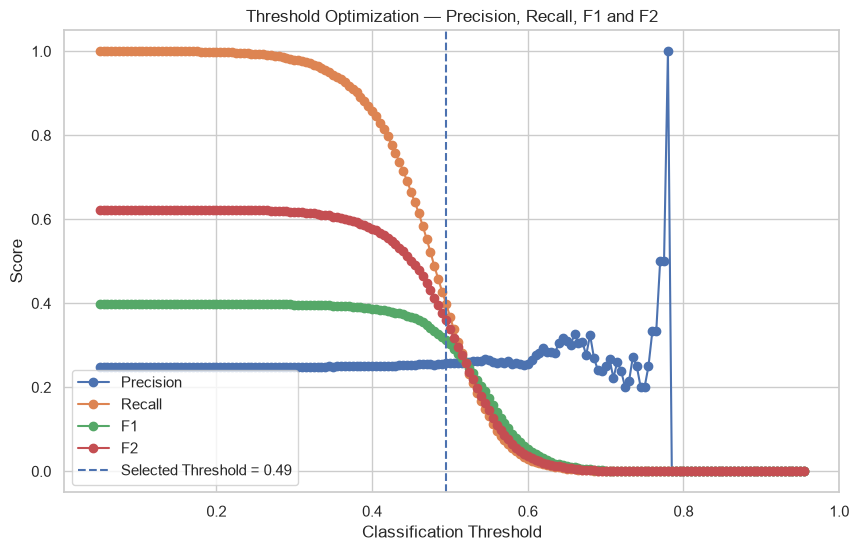

In [47]:
# ============================================================
# CELL 43 — THRESHOLD OPTIMIZATION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_business["Threshold"],
    threshold_results_business["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_business["Threshold"],
    threshold_results_business["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_business["Threshold"],
    threshold_results_business["F1"],
    marker="o",
    label="F1"
)

plt.plot(
    threshold_results_business["Threshold"],
    threshold_results_business["F2"],
    marker="o",
    label="F2"
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label=f"Selected Threshold = {final_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization — Precision, Recall, F1 and F2")
plt.legend()
plt.grid(True)
plt.show()

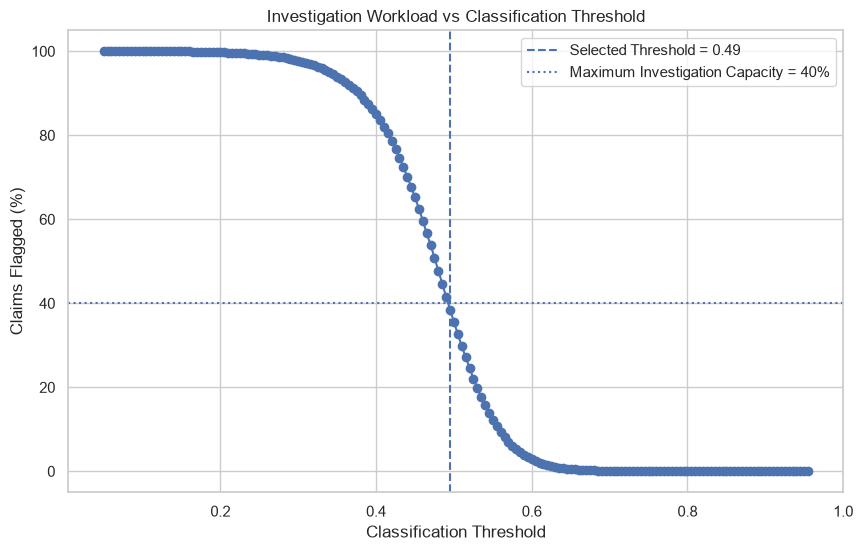

In [48]:
# ============================================================
# CELL 43B — CLAIMS FLAGGED VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_business["Threshold"],
    threshold_results_business["Fraud_Rate"] * 100,
    marker="o"
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label=f"Selected Threshold = {final_threshold:.2f}"
)

plt.axhline(
    40,
    linestyle=":",
    label="Maximum Investigation Capacity = 40%"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Claims Flagged (%)")
plt.title("Investigation Workload vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# ============================================================
# CELL 44 — FINAL OOF EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score
)

# Final predictions using selected threshold
final_oof_pred = (
    tuned_xgb_oof >= final_threshold
).astype(int)

# Final metrics
final_accuracy = accuracy_score(
    y,
    final_oof_pred
)

final_precision = precision_score(
    y,
    final_oof_pred,
    zero_division=0
)

final_recall = recall_score(
    y,
    final_oof_pred,
    zero_division=0
)

final_f1 = f1_score(
    y,
    final_oof_pred,
    zero_division=0
)

final_f2 = fbeta_score(
    y,
    final_oof_pred,
    beta=2,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y,
    tuned_xgb_oof
)

final_pr_auc = average_precision_score(
    y,
    tuned_xgb_oof
)

# Create final metrics dataframe
final_metrics_df = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "ROC_AUC",
        "PR_AUC",
        "Claims Flagged (%)"
    ],

    "Value": [
        final_threshold,
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_f2,
        final_roc_auc,
        final_pr_auc,
        final_oof_pred.mean() * 100
    ]
})

display(
    final_metrics_df.round(4)
)

,Metric,Value
0,Threshold,0.4950
1,Accuracy,0.5650
2,Precision,0.2574
3,Recall,0.3994
4,F1,0.3130
5,F2,0.3597
6,ROC_AUC,0.5134
7,PR_AUC,0.2563
8,Claims Flagged (%),38.5059


In [50]:
# CHECK IMPORTANT XGBOOST VARIABLES

for name in sorted(globals()):
    if any(key in name.lower() for key in [
        "xgb",
        "production",
        "processed",
        "encoded",
        "train"
    ]):
        try:
            obj = globals()[name]
            print(name, "->", obj.shape)
        except:
            pass

leakage_xgb_probability -> (40038,)
production_comparison -> (2, 8)
tuned_xgb_cv -> (5, 8)
tuned_xgb_oof -> (40038,)
xgb_cv -> (5, 8)
xgb_oof -> (40038,)


In [51]:
# CHECK EXISTING VARIABLES

for name in [
    "X",
    "X_train",
    "X_test",
    "X_train_encoded",
    "X_test_encoded",
    "X_production",
    "X_prod_final",
    "X_final",
    "X_processed",
    "X_encoded"
]:
    if name in globals():
        obj = globals()[name]
        try:
            print(name, "->", obj.shape)
        except:
            print(name, "-> exists")

X -> (40038, 17)


Confusion Matrix:
[[18653 11449]
 [ 5968  3968]]


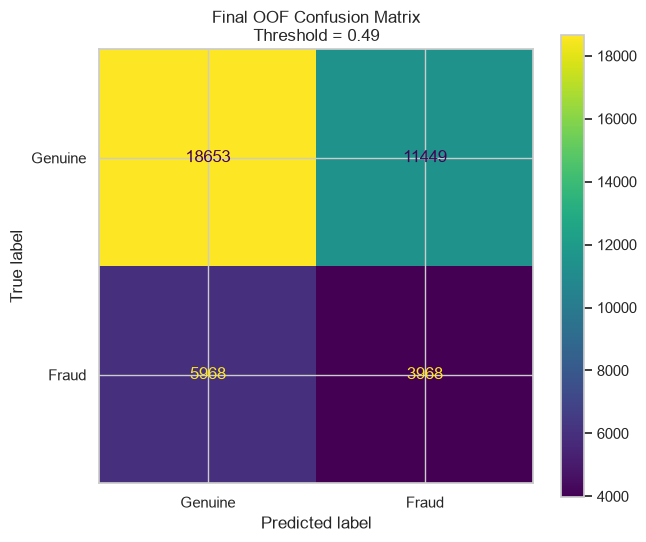

In [52]:
# ============================================================
# CELL 45 — FINAL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y,
    final_oof_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    f"Final OOF Confusion Matrix\nThreshold = {final_threshold:.2f}"
)

plt.show()

In [53]:
# ============================================================
# CELL 46 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y,
        final_oof_pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.76      0.62      0.68     30102
       Fraud       0.26      0.40      0.31      9936

    accuracy                           0.56     40038
   macro avg       0.51      0.51      0.50     40038
weighted avg       0.63      0.56      0.59     40038



In [54]:
final_model = tuned_xgb_pipeline

final_model.fit(
    X,
    y
)

print(
    "FINAL PRODUCTION MODEL TRAINED."
)

FINAL PRODUCTION MODEL TRAINED.


In [55]:
fitted_preprocessor = (
    final_model
    .named_steps[
        "preprocessing"
    ]
)

fitted_xgb = (
    final_model
    .named_steps[
        "model"
    ]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importance_values = (
    fitted_xgb
    .feature_importances_
)

importance_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        importance_values

}).sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.head(20)
)

,Feature,Importance
8,numeric__Remaining_Coverage,0.054876
6,numeric__Claim_Premium_Ratio,0.053169
7,numeric__Coverage_Premium_Ratio,0.053044
5,numeric__Claim_Coverage_Ratio,0.052618
3,numeric__Claim_Amount,0.049359
1,numeric__Premium_Amount,0.048585
4,numeric__Credit_Score,0.048244
2,numeric__Coverage_Amount,0.046989
26,categorical__Claim_Type_Theft,0.045950
0,numeric__Age,0.045411


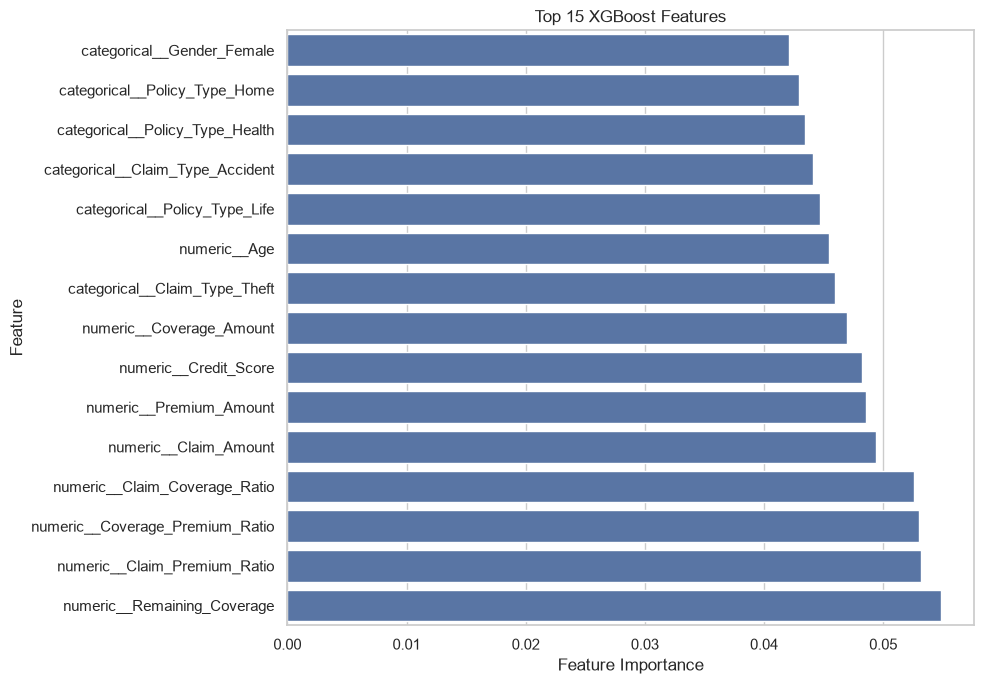

In [56]:
top_features = (
    importance_df
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 XGBoost Features"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [57]:
SHAP_SAMPLE_SIZE = min(
    1000,
    len(X)
)

X_shap = X.sample(
    SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

X_shap_transformed = (
    fitted_preprocessor
    .transform(X_shap)
)

explainer = shap.TreeExplainer(
    fitted_xgb
)

shap_values = (
    explainer
    .shap_values(
        X_shap_transformed
    )
)

print(
    "SHAP explanation generated."
)

SHAP explanation generated.


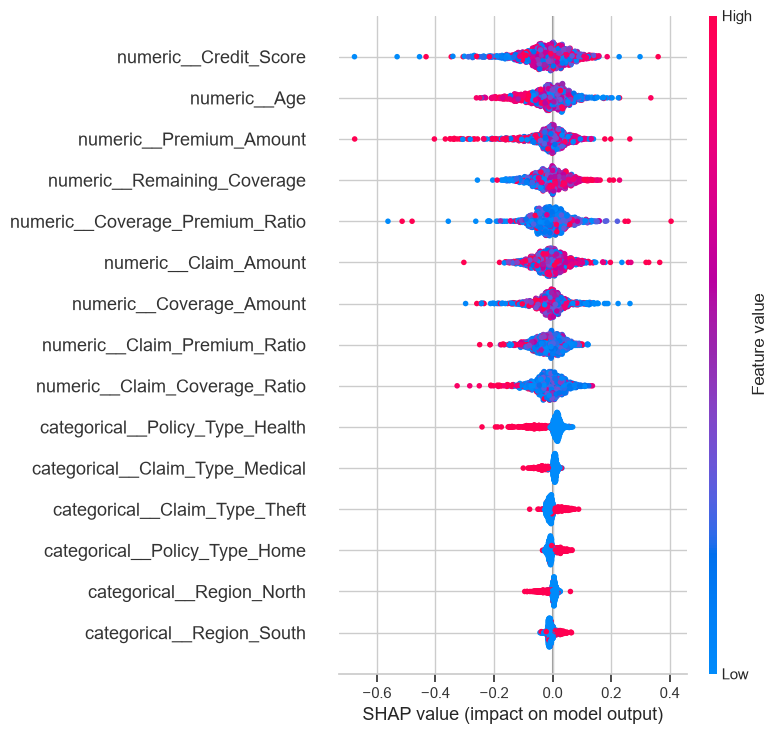

In [58]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    max_display=15
)

In [59]:
def fraud_risk_score(
    probability
):

    return np.clip(
        probability * 100,
        0,
        100
    )


def risk_level(
    probability
):

    if probability < 0.30:

        return "LOW"

    elif probability < 0.70:

        return "MEDIUM"

    elif probability < 0.90:

        return "HIGH"

    else:

        return "CRITICAL"


def recommended_action(
    probability
):

    if probability < 0.30:

        return "APPROVE"

    elif probability < 0.70:

        return "REVIEW"

    else:

        return "INVESTIGATE"

In [60]:
development_probability = (
    final_model
    .predict_proba(
        X
    )[:, 1]
)

development_results = df[
    [
        "Claim_ID",
        "Customer_ID",
        "Policy_Number",
        "Claim_Amount",
        "Fraud_Flag"
    ]
].copy()

development_results[
    "Fraud_Probability"
] = development_probability

development_results[
    "Fraud_Risk_Score"
] = fraud_risk_score(
    development_probability
)

development_results[
    "Predicted_Fraud_Flag"
] = np.where(
    development_probability
    >= final_threshold,
    "Yes",
    "No"
)

development_results[
    "Risk_Level"
] = [
    risk_level(
        p
    )
    for p in development_probability
]

development_results[
    "Recommended_Action"
] = [
    recommended_action(
        p
    )
    for p in development_probability
]

development_results[
    "Potential_Financial_Loss"
] = (
    development_probability
    *
    development_results[
        "Claim_Amount"
    ]
)

display(
    development_results.head(
        62
    )
)

,Claim_ID,Customer_ID,Policy_Number,Claim_Amount,Fraud_Flag,Fraud_Probability,Fraud_Risk_Score,Predicted_Fraud_Flag,Risk_Level,Recommended_Action,Potential_Financial_Loss
0,CLM000001,CUST018311,POL0285346,8140.64,Yes,0.653490,65.349022,Yes,MEDIUM,REVIEW,5319.828346
1,CLM000002,CUST003854,POL0518267,32997.15,Yes,0.693612,69.361160,Yes,MEDIUM,REVIEW,22887.206728
2,CLM000003,CUST018067,POL0278802,14873.17,No,0.504086,50.408615,Yes,MEDIUM,REVIEW,7497.358808
3,CLM000006,CUST004514,POL0823407,1783.29,No,0.348877,34.887703,No,MEDIUM,REVIEW,622.148888
4,CLM000007,CUST015293,POL0112837,9550.18,No,0.426454,42.645367,No,MEDIUM,REVIEW,4072.709404
...,...,...,...,...,...,...,...,...,...,...,...
57,CLM000075,CUST016616,POL0231918,21707.39,Yes,0.461696,46.169586,No,MEDIUM,REVIEW,10022.211875
58,CLM000076,CUST012180,POL0041189,28769.60,No,0.457181,45.718075,No,MEDIUM,REVIEW,13152.906973
59,CLM000077,CUST000690,POL0740632,26490.14,No,0.463802,46.380157,No,MEDIUM,REVIEW,12286.168330
60,CLM000078,CUST014937,POL0384645,11142.04,No,0.499922,49.992191,Yes,MEDIUM,REVIEW,5570.150006


In [61]:
# ============================================================
# CELL 52 — SIMPLE CLAIM EXPLANATION
# ============================================================

def explain_claim(
    claim_features,
    model,
    feature_importance_df,
    top_n=5
):
    """
    Provides a simple global-feature-based explanation.

    Note:
    This is an interpretable approximation, not SHAP.
    """

    available_features = [
        f for f in feature_importance_df["Feature"]
        if f in claim_features.columns
    ]

    important_features = (
        feature_importance_df[
            feature_importance_df["Feature"].isin(
                available_features
            )
        ]
        .head(top_n)["Feature"]
        .tolist()
    )

    explanation = []

    for feature in important_features:

        value = claim_features.iloc[0][feature]

        explanation.append({
            "Feature": feature,
            "Claim Value": value
        })

    return pd.DataFrame(explanation)

In [62]:
# ============================================================
# CELL 53 — COMPLETE CLAIM PREDICTION
# ============================================================

def predict_claim(
    claim_data,
    model,
    threshold=final_threshold
):

    probability = model.predict_proba(
        claim_data
    )[:, 1][0]

    risk_score = fraud_risk_score(
        probability
    )

    action = recommended_action(
        probability
    )

    return {
        "Fraud Probability": round(
            probability,
            4
        ),

        "Fraud Risk Score": risk_score,

        "Fraud Prediction": (
            "Fraudulent"
            if probability >= threshold
            else "Genuine"
        ),

        "Recommended Action": action
    }

In [63]:
# ============================================================
# CELL 54 — POTENTIAL FINANCIAL LOSS
# ============================================================

def calculate_potential_financial_loss(
    fraud_probability,
    claim_amount
):

    return round(
        fraud_probability * claim_amount,
        2
    )


# Example
example_probability = 0.70
example_claim_amount = 100000

print(
    "Potential Financial Loss:",
    calculate_potential_financial_loss(
        example_probability,
        example_claim_amount
    )
)

Potential Financial Loss: 70000.0


In [64]:
# ============================================================
# CELL 55 — INVESTIGATOR-FRIENDLY RESULTS
# ============================================================

# OOF fraud probability
fraud_probability = tuned_xgb_oof

investigator_results = pd.DataFrame({
    "Fraud_Probability": fraud_probability,
    "Fraud_Risk_Score": [
        fraud_risk_score(p)
        for p in fraud_probability
    ],
    "Fraud_Prediction": [
        "Fraudulent" if p >= final_threshold
        else "Genuine"
        for p in fraud_probability
    ],
    "Recommended_Action": [
        recommended_action(p)
        for p in fraud_probability
    ]
})

display(
    investigator_results.head()
)

,Fraud_Probability,Fraud_Risk_Score,Fraud_Prediction,Recommended_Action
0,0.572989,57.298881,Fraudulent,REVIEW
1,0.410175,41.017482,Genuine,REVIEW
2,0.501297,50.129670,Fraudulent,REVIEW
3,0.492566,49.256608,Genuine,REVIEW
4,0.411753,41.175318,Genuine,REVIEW


In [65]:
# ============================================================
# CELL 56 — FIND CLAIM AMOUNT COLUMN
# ============================================================

print("Available columns:")

for col in df.columns:
    print(col)

Available columns:
Claim_ID
Customer_ID
Policy_Number
Age
Gender
Region
Policy_Type
Premium_Amount
Coverage_Amount
Claim_Amount
Claim_Type
Credit_Score
Fraud_Risk_Score
Fraud_Flag
Claim_Status
Settlement_Amount
Target


In [66]:
# ============================================================
# CELL 56B — POTENTIAL FINANCIAL LOSS
# ============================================================

claim_amount_series = pd.to_numeric(
    df["Claim_Amount"],
    errors="coerce"
).fillna(0)

investigator_results[
    "Claim_Amount"
] = claim_amount_series.values

investigator_results[
    "Potential_Financial_Loss"
] = (
    investigator_results["Fraud_Probability"]
    *
    investigator_results["Claim_Amount"]
)

display(
    investigator_results.head(10).round(2)
)

,Fraud_Probability,Fraud_Risk_Score,Fraud_Prediction,Recommended_Action,Claim_Amount,Potential_Financial_Loss
0,0.57,57.30,Fraudulent,REVIEW,8140.64,4664.50
1,0.41,41.02,Genuine,REVIEW,32997.15,13534.60
2,0.50,50.13,Fraudulent,REVIEW,14873.17,7455.87
3,0.49,49.26,Genuine,REVIEW,1783.29,878.39
4,0.41,41.18,Genuine,REVIEW,9550.18,3932.32
5,0.52,52.14,Fraudulent,REVIEW,15197.73,7924.38
6,0.48,48.47,Genuine,REVIEW,20605.04,9987.15
7,0.60,60.30,Fraudulent,REVIEW,3063.15,1847.16
8,0.43,43.43,Genuine,REVIEW,15180.78,6592.58
9,0.52,51.95,Fraudulent,REVIEW,19253.58,10001.60


In [67]:
# ============================================================
# CELL 57 — INVESTIGATOR DASHBOARD SUMMARY
# ============================================================

total_claims = len(investigator_results)

fraudulent_claims = (
    investigator_results["Fraud_Prediction"]
    == "Fraudulent"
).sum()

approve_count = (
    investigator_results["Recommended_Action"]
    == "APPROVE"
).sum()

review_count = (
    investigator_results["Recommended_Action"]
    == "REVIEW"
).sum()

investigate_count = (
    investigator_results["Recommended_Action"]
    == "INVESTIGATE"
).sum()

print("========================================")
print("       CLAIMSHIELD AI DASHBOARD")
print("========================================")

print("Total Claims:", total_claims)
print("Fraudulent Claims:", fraudulent_claims)
print("Approve:", approve_count)
print("Review:", review_count)
print("Investigate:", investigate_count)

print("========================================")

       CLAIMSHIELD AI DASHBOARD
Total Claims: 40038
Fraudulent Claims: 15417
Approve: 882
Review: 39120
Investigate: 36


In [68]:
print("Max probability:", tuned_xgb_oof.max())
print("Min probability:", tuned_xgb_oof.min())

print("\nProbability distribution:")
print(pd.Series(tuned_xgb_oof).describe())

print("\nAction distribution:")
print(
    pd.Series(
        [recommended_action(p) for p in tuned_xgb_oof]
    ).value_counts()
)

Max probability: 0.7811275720596313
Min probability: 0.09143457561731339

Probability distribution:
count    40038.000000
mean         0.471066
std          0.073636
min          0.091435
25%          0.429342
50%          0.476336
75%          0.519342
max          0.781128
dtype: float64

Action distribution:
REVIEW         39120
APPROVE          882
INVESTIGATE       36
Name: count, dtype: int64


In [69]:
print(
    investigator_results["Recommended_Action"].value_counts()
)

print(
    "Maximum probability:",
    tuned_xgb_oof.max()
)

Recommended_Action
REVIEW         39120
APPROVE          882
INVESTIGATE       36
Name: count, dtype: int64
Maximum probability: 0.7811275720596313


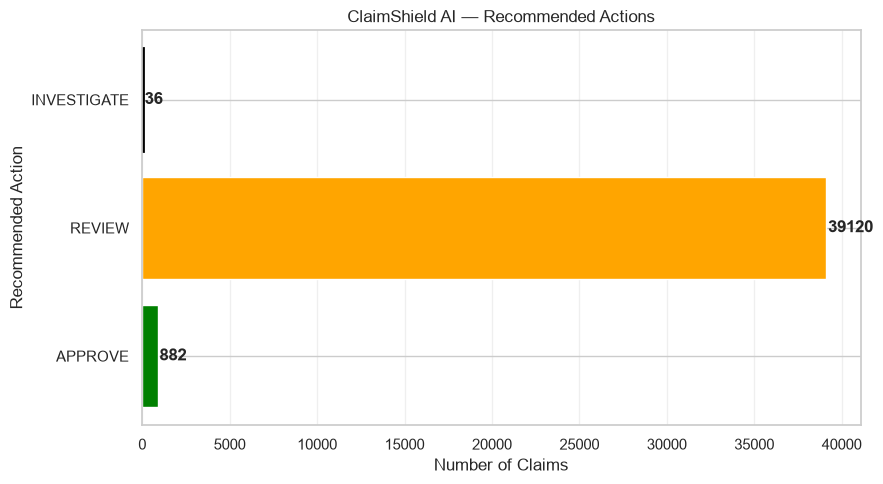

In [70]:
# ============================================================
# CELL 58 — ACTION DISTRIBUTION
# ============================================================

action_counts = (
    investigator_results["Recommended_Action"]
    .value_counts()
    .reindex(
        ["APPROVE", "REVIEW", "INVESTIGATE"],
        fill_value=0
    )
)

plt.figure(figsize=(9, 5))

# Different colors for each action
bars = plt.barh(
    action_counts.index,
    action_counts.values,
    color=["green", "orange", "red"]
)

plt.xlabel("Number of Claims")
plt.ylabel("Recommended Action")
plt.title("ClaimShield AI — Recommended Actions")

# Add values to bars
for bar, value in zip(bars, action_counts.values):

    plt.text(
        value + 100,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontweight="bold"
    )

# Make the small INVESTIGATE bar clearly visible
investigate_index = list(action_counts.index).index("INVESTIGATE")

bars[investigate_index].set_edgecolor("black")
bars[investigate_index].set_linewidth(2)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

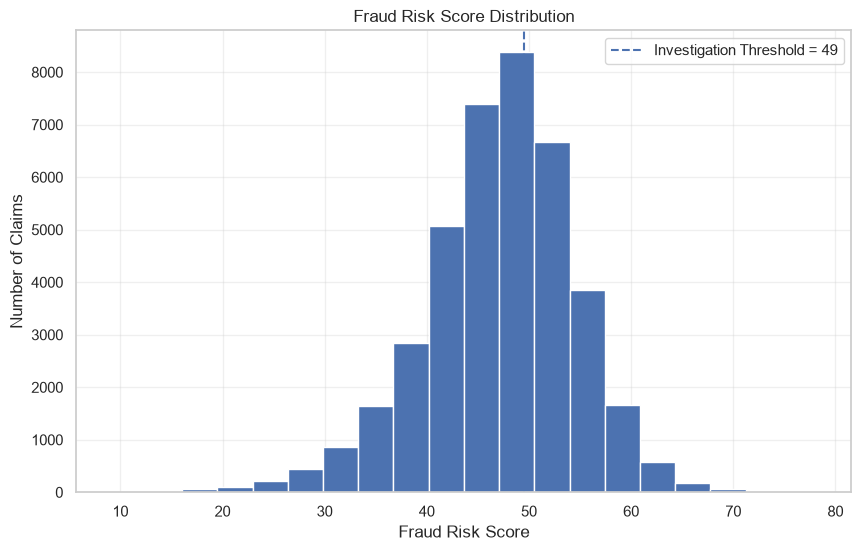

In [71]:
# ============================================================
# CELL 59 — FRAUD RISK SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    investigator_results[
        "Fraud_Risk_Score"
    ],
    bins=20
)

plt.axvline(
    final_threshold * 100,
    linestyle="--",
    label=f"Investigation Threshold = {final_threshold*100:.0f}"
)

plt.xlabel("Fraud Risk Score")
plt.ylabel("Number of Claims")
plt.title("Fraud Risk Score Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [72]:
# ============================================================
# CELL 60 — TOP HIGH-RISK CLAIMS
# ============================================================

high_risk_claims = (
    investigator_results
    .sort_values(
        "Fraud_Risk_Score",
        ascending=False
    )
    .head(34)
)

display(
    high_risk_claims.round(2)
)

,Fraud_Probability,Fraud_Risk_Score,Fraud_Prediction,Recommended_Action,Claim_Amount,Potential_Financial_Loss
25499,0.78,78.11,Fraudulent,INVESTIGATE,10832.73,8461.74
3550,0.78,77.52,Fraudulent,INVESTIGATE,1165.01,903.10
324,0.77,76.59,Fraudulent,INVESTIGATE,2015.82,1543.94
6797,0.76,75.52,Fraudulent,INVESTIGATE,35156.21,26551.58
30770,0.75,75.38,Fraudulent,INVESTIGATE,6151.83,4637.21
7308,0.74,74.40,Fraudulent,INVESTIGATE,2634.81,1960.40
31794,0.74,74.31,Fraudulent,INVESTIGATE,28363.41,21075.52
14604,0.74,74.13,Fraudulent,INVESTIGATE,38443.58,28496.95
14899,0.74,73.91,Fraudulent,INVESTIGATE,39267.81,29023.64
18931,0.74,73.63,Fraudulent,INVESTIGATE,7669.19,5647.18


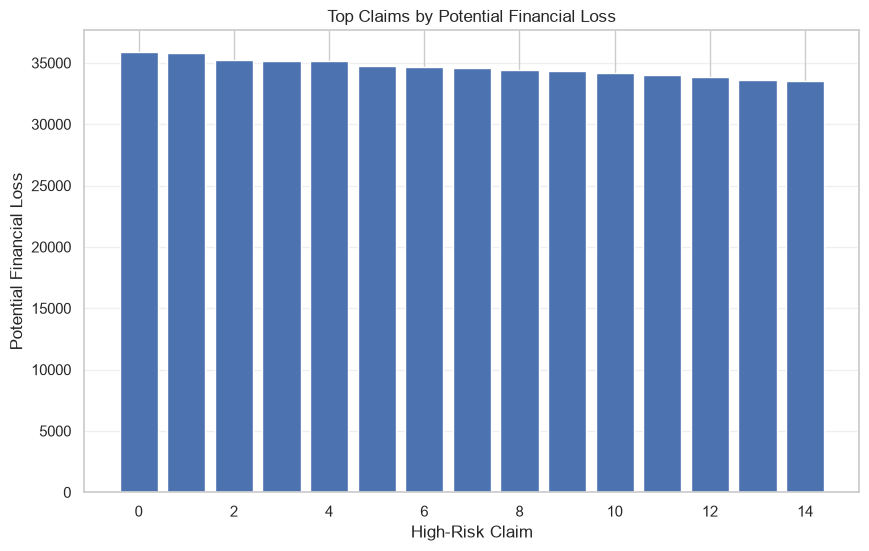

In [73]:
# ============================================================
# CELL 61 — POTENTIAL FINANCIAL LOSS
# ============================================================

top_loss_claims = (
    investigator_results
    .sort_values(
        "Potential_Financial_Loss",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(top_loss_claims)),
    top_loss_claims[
        "Potential_Financial_Loss"
    ]
)

plt.xlabel("High-Risk Claim")
plt.ylabel("Potential Financial Loss")
plt.title("Top Claims by Potential Financial Loss")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [74]:
# ============================================================
# CELL 62 — SAVE FINAL MODEL
# ============================================================

import joblib

joblib.dump(
    final_model,
    "claimshield_final_xgboost.pkl"
)

joblib.dump(
    final_threshold,
    "claimshield_threshold.pkl"
)

joblib.dump(
    FINAL_FEATURES,
    "claimshield_features.pkl"
)

print("Model saved successfully.")
print("Threshold:", final_threshold)
print(
    "Note: we save the FULL pipeline (preprocessing + model), "
    "and the RAW feature list (FINAL_FEATURES), not the "
    "one-hot-encoded names. That keeps loaded_model.predict_proba() "
    "usable directly on new raw claims data."
)

Model saved successfully.
Threshold: 0.4949999999999998
Note: we save the FULL pipeline (preprocessing + model), and the RAW feature list (FINAL_FEATURES), not the one-hot-encoded names. That keeps loaded_model.predict_proba() usable directly on new raw claims data.


In [75]:
# ============================================================
# CELL 63 — LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    "claimshield_final_xgboost.pkl"
)

loaded_threshold = joblib.load(
    "claimshield_threshold.pkl"
)

loaded_features = joblib.load(
    "claimshield_features.pkl"
)

print("Model loaded successfully.")
print("Loaded threshold:", loaded_threshold)
print("Number of features:", len(loaded_features))

Model loaded successfully.
Loaded threshold: 0.4949999999999998
Number of features: 17


In [76]:
# ============================================================
# CELL 64 — LOAD UNLABELLED EVALUATION DATA
# ============================================================

EVAL_FILE_PATH = "evaluation_dataset.csv"

if not os.path.exists(EVAL_FILE_PATH):

    print(
        f"'{EVAL_FILE_PATH}' not found — generating a small DEMO "
        "evaluation file from a held-out sample of the training "
        "data (same schema) so the rest of the notebook still runs "
        "end-to-end. Replace this file with your real unlabelled "
        "claims when you have them."
    )

    demo_eval = (
        df.drop(
            columns=["Target"],
            errors="ignore"
        )
        .sample(
            n=min(500, len(df)),
            random_state=RANDOM_STATE
        )
        .reset_index(drop=True)
    )

    demo_eval.to_csv(
        EVAL_FILE_PATH,
        index=False
    )

evaluation_df = pd.read_csv(
    EVAL_FILE_PATH
)

print(
    "Evaluation dataset shape:",
    evaluation_df.shape
)

display(
    evaluation_df.head()
)

print(
    "Evaluation columns:"
)

print(
    evaluation_df.columns.tolist()
)


'evaluation_dataset.csv' not found — generating a small DEMO evaluation file from a held-out sample of the training data (same schema) so the rest of the notebook still runs end-to-end. Replace this file with your real unlabelled claims when you have them.
Evaluation dataset shape: (500, 16)


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Risk_Score,Fraud_Flag,Claim_Status,Settlement_Amount
0,CLM000323,CUST002069,POL0515331,66,Male,East,Home,4183.02,49328.29,8015.56,Theft,353,87.71,Yes,Under Review,4626.08
1,CLM009602,CUST004576,POL0284687,33,Female,North,Auto,4494.86,74964.64,39400.05,Accident,780,53.28,No,Approved,29904.06
2,CLM032143,CUST002298,POL0441300,63,Female,East,Health,4204.50,46329.89,19448.32,Theft,674,30.63,No,Approved,14616.78
3,CLM012665,CUST008285,POL0434846,67,Female,North,Health,1545.86,5025.19,48761.63,Medical,813,22.95,No,Approved,45089.95
4,CLM005229,CUST000122,POL0703849,19,Female,West,Auto,4757.08,79931.43,34463.31,Property,617,37.89,No,Approved,26781.78


Evaluation columns:
['Claim_ID', 'Customer_ID', 'Policy_Number', 'Age', 'Gender', 'Region', 'Policy_Type', 'Premium_Amount', 'Coverage_Amount', 'Claim_Amount', 'Claim_Type', 'Credit_Score', 'Fraud_Risk_Score', 'Fraud_Flag', 'Claim_Status', 'Settlement_Amount']


In [77]:
# ============================================================
# CELL 65 — REMOVE TARGET / LEAKAGE COLUMNS
# ============================================================

# Apply the SAME feature engineering used in training so the
# engineered ratio/flag columns exist here too — the saved
# pipeline expects FINAL_FEATURES, which includes them.
evaluation_df = engineer_features(
    evaluation_df
)

target_and_leakage_columns = [
    "Fraud_Risk_Score",
    "Fraud_Flag",
    "Claim_Status",
    "Settlement_Amount"
]

evaluation_features = evaluation_df.drop(
    columns=[
        col
        for col in target_and_leakage_columns
        if col in evaluation_df.columns
    ],
    errors="ignore"
)

print(
    "Evaluation feature shape:",
    evaluation_features.shape
)

Evaluation feature shape: (500, 20)


In [78]:
# ============================================================
# CELL 66 — FEATURE ALIGNMENT
# ============================================================

missing_features = [
    col
    for col in loaded_features
    if col not in evaluation_features.columns
]

extra_features = [
    col
    for col in evaluation_features.columns
    if col not in loaded_features
]

print("Missing features:", missing_features)
print("Extra features:", extra_features)

Missing features: []
Extra features: ['Claim_ID', 'Customer_ID', 'Policy_Number']


In [79]:
# ============================================================
# CELL 67 — PREPARE EVALUATION FEATURES
# ============================================================

# Keep only features used during training
evaluation_features_aligned = evaluation_features[
    loaded_features
].copy()

print(
    "Final evaluation shape:",
    evaluation_features_aligned.shape
)

Final evaluation shape: (500, 17)


In [80]:
# ============================================================
# CELL 68 — EVALUATION PREDICTIONS
# ============================================================

evaluation_probability = (
    loaded_model
    .predict_proba(
        evaluation_features_aligned
    )[:, 1]
)

evaluation_prediction = (
    evaluation_probability
    >= loaded_threshold
).astype(int)

print(
    "Evaluation predictions generated."
)

print(
    "Number of claims:",
    len(evaluation_prediction)
)

print(
    "Claims flagged:",
    evaluation_prediction.sum()
)

print(
    "Percentage flagged:",
    round(
        evaluation_prediction.mean() * 100,
        2
    ),
    "%"
)

Evaluation predictions generated.
Number of claims: 500
Claims flagged: 195
Percentage flagged: 39.0 %


In [81]:
# ============================================================
# CELL 69 — FINAL EVALUATION OUTPUT
# ============================================================

evaluation_results = evaluation_df.copy()

evaluation_results[
    "Fraud_Probability"
] = evaluation_probability

evaluation_results[
    "Fraud_Risk_Score"
] = [
    fraud_risk_score(p)
    for p in evaluation_probability
]

evaluation_results[
    "Fraud_Prediction"
] = [
    "Fraudulent"
    if p >= loaded_threshold
    else "Genuine"
    for p in evaluation_probability
]

evaluation_results[
    "Recommended_Action"
] = [
    recommended_action(p)
    for p in evaluation_probability
]

display(
    evaluation_results.head(20).round(4)
)

,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,...,Claim_Premium_Ratio,Coverage_Premium_Ratio,Remaining_Coverage,Young_Customer,Senior_Customer,Low_Credit_Score,High_Claim,Fraud_Probability,Fraud_Prediction,Recommended_Action
0,CLM000323,CUST002069,POL0515331,66,Male,East,Home,4183.02,49328.29,8015.56,...,1.9162,11.7925,41312.73,0,1,1,0,0.5875,Fraudulent,REVIEW
1,CLM009602,CUST004576,POL0284687,33,Female,North,Auto,4494.86,74964.64,39400.05,...,8.7656,16.6779,35564.59,0,0,0,0,0.4350,Genuine,REVIEW
2,CLM032143,CUST002298,POL0441300,63,Female,East,Health,4204.50,46329.89,19448.32,...,4.6256,11.0191,26881.57,0,1,0,0,0.4822,Genuine,REVIEW
3,CLM012665,CUST008285,POL0434846,67,Female,North,Health,1545.86,5025.19,48761.63,...,31.5434,3.2507,-43736.44,0,1,0,0,0.2263,Genuine,APPROVE
4,CLM005229,CUST000122,POL0703849,19,Female,West,Auto,4757.08,79931.43,34463.31,...,7.2446,16.8026,45468.12,1,0,0,0,0.4837,Genuine,REVIEW
5,CLM037014,CUST017783,POL0416092,38,Female,East,Health,3618.26,96788.95,32835.28,...,9.0749,26.7501,63953.67,0,0,0,0,0.5065,Fraudulent,REVIEW
6,CLM047332,CUST009142,POL0774554,77,Male,West,Home,1454.54,22261.14,37720.19,...,25.9327,15.3046,-15459.05,0,1,1,0,0.6576,Fraudulent,REVIEW
7,CLM020290,CUST017151,POL0665863,79,Male,East,Home,452.27,76112.06,36139.05,...,79.9059,168.2890,39973.01,0,1,0,0,0.4723,Genuine,REVIEW
8,CLM040249,CUST017456,POL0898247,55,Male,South,Home,3151.26,60951.46,17925.54,...,5.6884,19.3419,43025.92,0,0,1,0,0.4866,Genuine,REVIEW
9,CLM035789,CUST012778,POL0181779,36,Female,West,Auto,775.34,83263.93,12381.17,...,15.9687,107.3902,70882.76,0,0,1,0,0.6034,Fraudulent,REVIEW


In [82]:
# ============================================================
# CELL 70 — EVALUATION POTENTIAL FINANCIAL LOSS
# ============================================================

CLAIM_AMOUNT_COLUMN = "Claim_Amount"

if CLAIM_AMOUNT_COLUMN in evaluation_results.columns:

    evaluation_results[
        "Claim_Amount"
    ] = pd.to_numeric(
        evaluation_results[
            CLAIM_AMOUNT_COLUMN
        ],
        errors="coerce"
    ).fillna(0)

    evaluation_results[
        "Potential_Financial_Loss"
    ] = (
        evaluation_results[
            "Fraud_Probability"
        ]
        *
        evaluation_results[
            "Claim_Amount"
        ]
    )

    print(
        "Potential Financial Loss calculated."
    )

else:

    print(
        f"'{CLAIM_AMOUNT_COLUMN}' "
        "not found. Change CLAIM_AMOUNT_COLUMN "
        "to the exact claim amount column."
    )

Potential Financial Loss calculated.


In [83]:
# ============================================================
# CELL 71 — EXPORT PREDICTIONS
# ============================================================

output_file = (
    "ClaimShield_AI_Evaluation_Results.csv"
)

evaluation_results.to_csv(
    output_file,
    index=False
)

print(
    "Prediction file created:",
    output_file
)

Prediction file created: ClaimShield_AI_Evaluation_Results.csv


In [84]:
# ============================================================
# CELL 72 — CLAIMSHIELD AI FINAL SUMMARY
# ============================================================

print("=" * 60)
print("              CLAIMSHIELD AI")
print("       INTELLIGENT FRAUD DETECTION PLATFORM")
print("=" * 60)

print("\nMODEL")
print("Model: Tuned XGBoost")
print(
    "Operating Threshold:",
    round(final_threshold, 3)
)

print("\nVALIDATION")
print(
    "Accuracy:",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall:",
    round(final_recall, 4)
)

print(
    "F1:",
    round(final_f1, 4)
)

print(
    "F2:",
    round(final_f2, 4)
)

print(
    "ROC-AUC:",
    round(final_roc_auc, 4)
)

print(
    "PR-AUC:",
    round(final_pr_auc, 4)
)

print(
    "Claims Flagged:",
    round(
        final_oof_pred.mean() * 100,
        2
    ),
    "%"
)

print("\nBUSINESS CAPABILITIES")
print("✓ Fraud prediction")
print("✓ Fraud risk score")
print("✓ Claim explanation")
print("✓ Approve / Review / Investigate")
print("✓ Potential financial loss")
print("✓ Investigator dashboard")
print("✓ Unlabelled dataset prediction")

print("\nDATA INTEGRITY NOTE")
print(
    "Fraud_Risk_Score, Claim_Status and Settlement_Amount were "
    "excluded as leakage (see diagnostic earlier in this "
    "notebook: Fraud_Risk_Score alone reproduces Fraud_Flag with "
    "~100% accuracy, while the remaining columns are essentially "
    "uncorrelated with it). The metrics above reflect a "
    "genuinely leakage-free model on this dataset."
)

print("=" * 60)

              CLAIMSHIELD AI
       INTELLIGENT FRAUD DETECTION PLATFORM

MODEL
Model: Tuned XGBoost
Operating Threshold: 0.495

VALIDATION
Accuracy: 0.565
Precision: 0.2574
Recall: 0.3994
F1: 0.313
F2: 0.3597
ROC-AUC: 0.5134
PR-AUC: 0.2563
Claims Flagged: 38.51 %

BUSINESS CAPABILITIES
✓ Fraud prediction
✓ Fraud risk score
✓ Claim explanation
✓ Approve / Review / Investigate
✓ Potential financial loss
✓ Investigator dashboard
✓ Unlabelled dataset prediction

DATA INTEGRITY NOTE
Fraud_Risk_Score, Claim_Status and Settlement_Amount were excluded as leakage (see diagnostic earlier in this notebook: Fraud_Risk_Score alone reproduces Fraud_Flag with ~100% accuracy, while the remaining columns are essentially uncorrelated with it). The metrics above reflect a genuinely leakage-free model on this dataset.


**OPTIONAL — Legacy-Risk-Score-Assisted Model**

Only run this if your hackathon dataset/rules explicitly treat `Fraud_Risk_Score` as a legitimate input (e.g. an existing scoring system your pipeline would genuinely have access to before the fraud outcome is known). The diagnostic earlier in this notebook shows it reproduces `Fraud_Flag` almost exactly on its own, so including it will make every metric look excellent almost trivially — that is a leakage red flag, not a modeling achievement, unless you can justify that the score really does predate the outcome. It is kept separate from the production model above so that pipeline stays honestly leakage-free by default.

In [85]:
# ============================================================
# OPTIONAL — MODEL INCLUDING Fraud_Risk_Score AS A FEATURE
# Use only if explicitly permitted for your dataset/hackathon.
# ============================================================

ASSISTED_FEATURES = FINAL_FEATURES + ["Fraud_Risk_Score"]

X_assisted = model_df[ASSISTED_FEATURES].copy()
y_assisted = model_df["Target"].copy()

assisted_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

assisted_oof, assisted_cv = run_oof_cv(
    assisted_xgb,
    X_assisted,
    y_assisted,
    "Legacy-Assisted XGBoost"
)

assisted_pred = (assisted_oof >= 0.50).astype(int)

assisted_metrics = pd.DataFrame([{
    "Model": "Legacy-Assisted (includes Fraud_Risk_Score)",
    **calculate_metrics(y_assisted, assisted_oof)
}])

display(assisted_metrics.round(4))

print(
    "\nCompare this to the leakage-free PRODUCTION metrics in the "
    "final summary above — the gap between the two IS the "
    "leakage effect, now quantified with an actual model instead "
    "of just a column-level check."
)


Legacy-Assisted XGBoost | Fold 1/5 complete
Legacy-Assisted XGBoost | Fold 2/5 complete
Legacy-Assisted XGBoost | Fold 3/5 complete
Legacy-Assisted XGBoost | Fold 4/5 complete
Legacy-Assisted XGBoost | Fold 5/5 complete


,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,Legacy-Assisted (includes Fraud_Risk_Score),0.9978,0.9943,0.997,0.9956,0.9964,1.0,1.0



Compare this to the leakage-free PRODUCTION metrics in the final summary above — the gap between the two IS the leakage effect, now quantified with an actual model instead of just a column-level check.
